<a id="summary"></a>


# Welcome to the **Mastering RAG Systems** hands-on guide!

Highly Recommend going through these easy to understand **slides**, first so you have an intial image in your mind: 

[Link](https://www.linkedin.com/posts/musaoc_a-beginner-friendly-easy-to-understand-rag-ugcPost-7484924260885381121-TzSj/?utm_source=share&utm_medium=member_desktop&rcm=ACoAADfWcjsBcvIZb5ywW6ZHCljn7-HB1PRMHMs)




---

### Dataset being used:

| File | Type | Size | Key Columns | Role in This Notebook |
|------|------|------|-------------|----------------------|
| `data/customer_support.csv` | Structured CSV | ~13,000 rows | `instruction`, `response`, `category`, `intent` | FAQ Q&A pairs — 500 sampled rows indexed into the vector store |
| `data/policy_handbook.md` | Unstructured Markdown | ~5,000 chars | Sections split by `## Section` headers | Document RAG — The Purpose of it in this notebook is to show you chunking techniques |



---

**Table of Contents**
> * [Setup & Configuration](#setup)
> * [Module 1: Foundations](#module1)
> * [Module 2: Text Embeddings & Vector Space](#module2)
> * [Module 3: Document Processing & Chunking](#module3)
> * [Module 4: Vector Databases & Dual-Corpus Indexing](#module4)
> * [Module 5: Hybrid Retrieval & RRF](#module5)
> * [Module 6: Two-Stage Reranking](#module6)
> * [Module 7: Prompt Engineering & Grounded Generation](#module7)
> * [Module 8: Evaluation & The RAG Triad](#module8)
>
> ---

# End-to-End Pipeline

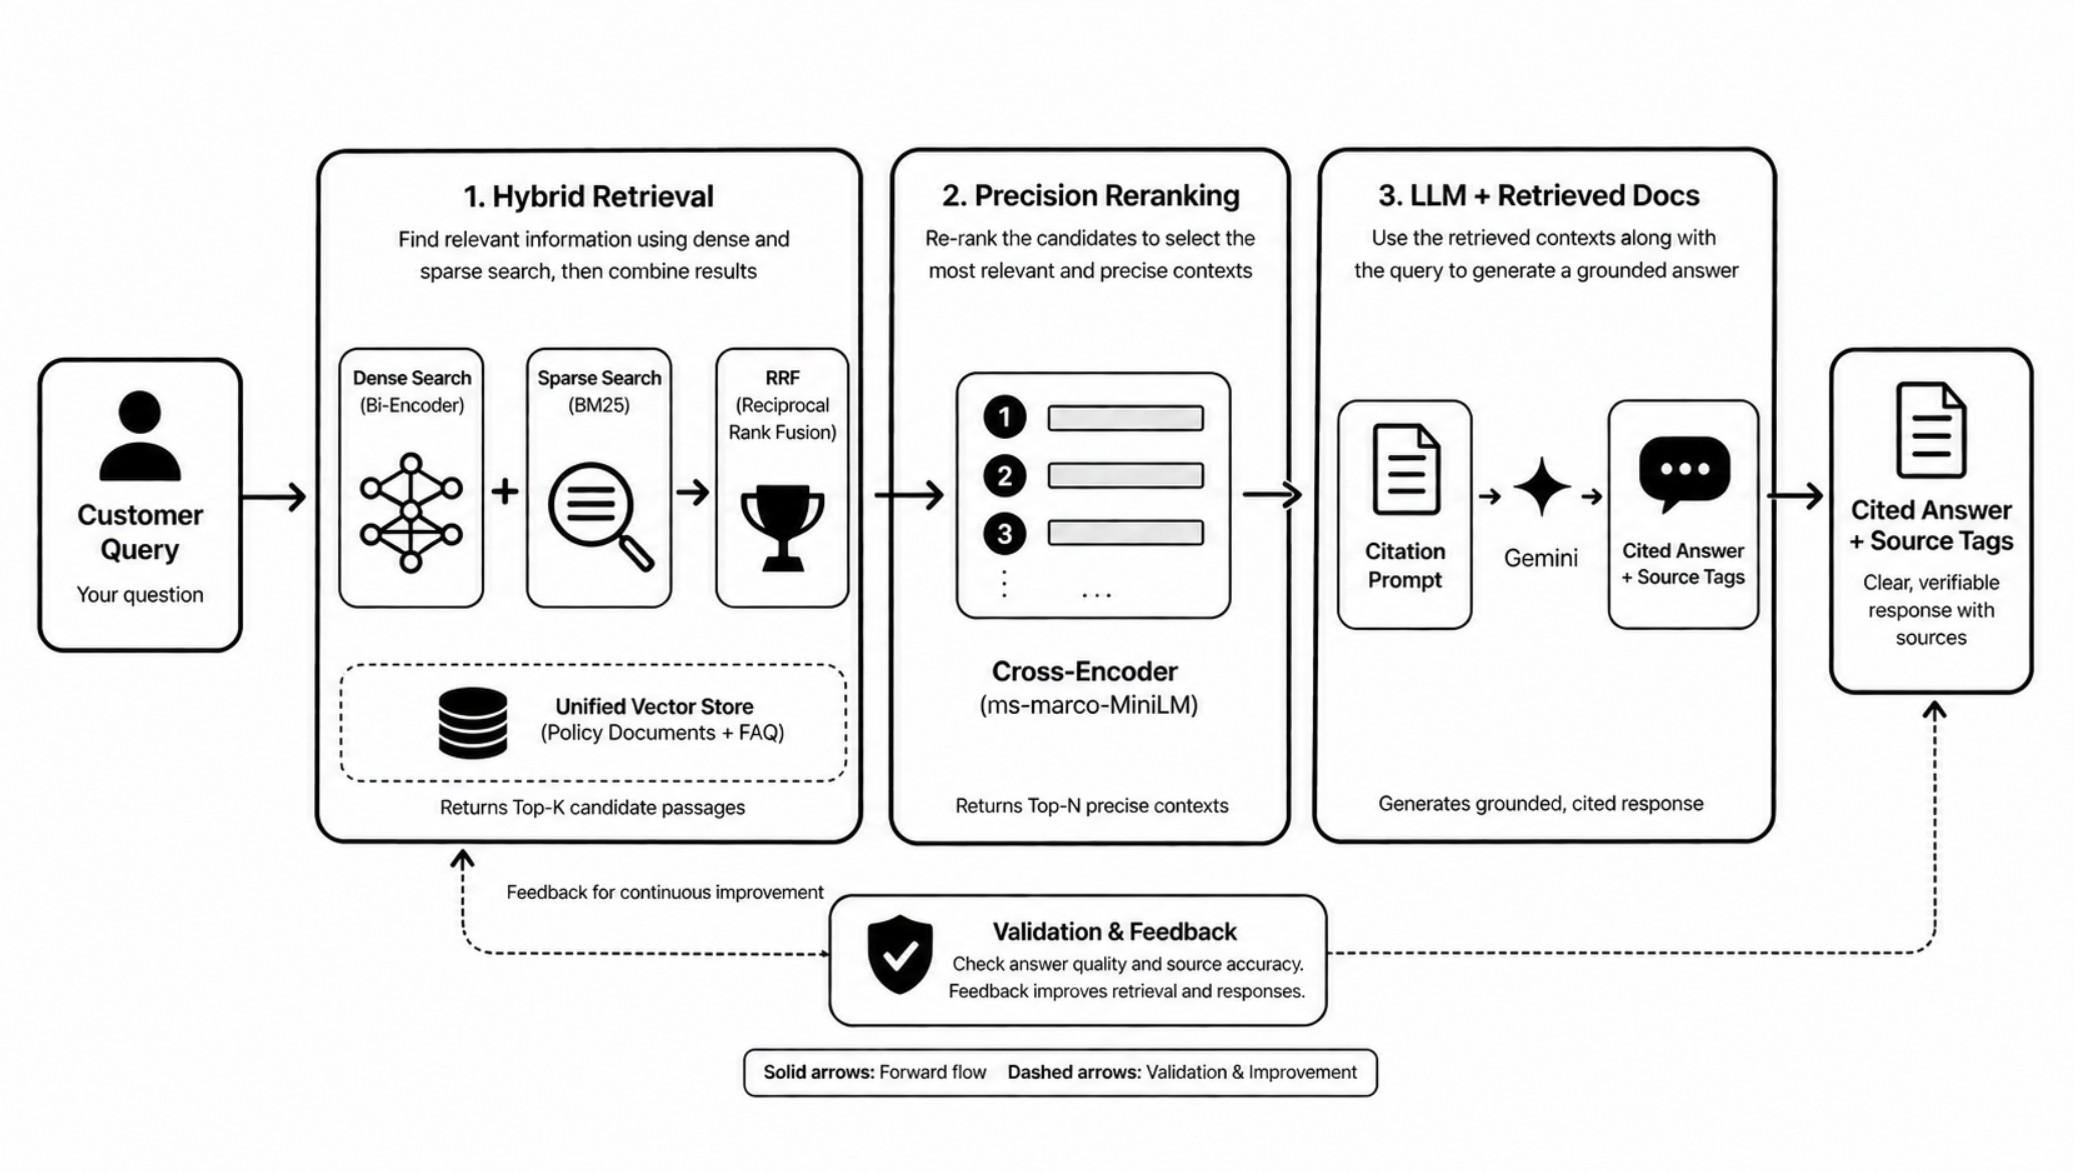

<a id="setup"></a>
## Setup & Configuration

Configure your Gemini API key using **one** of the three methods below. **All pipeline modules work without a key** — the notebook automatically falls back to a local mock generator so you can follow every step.

In [ ]:
import os

# ── API Key ───────────────────────────────────────────────────────────────
# Method 1 (Kaggle) : Notebook Settings > Secrets > add key named 'GEMINI_API_KEY'
# Method 2 (Local)  : Create a .env file containing  GEMINI_API_KEY=your_key_here
# Method 3 (Manual) : Paste your key directly into the variable below

GEMINI_API_KEY = ""  # <-- paste key here for quick testing (Dont Make Public, if you want to make public use Kaggle Secrets)

# ── Model ─────────────────────────────────────────────────────────────────
# Change this single variable to switch models across the entire notebook.
GEMINI_MODEL = "gemini-3.1-flash-lite"

# Auto-detect: Kaggle Secrets
if not GEMINI_API_KEY:
    try:
        from kaggle_secrets import UserSecretsClient
        GEMINI_API_KEY = UserSecretsClient().get_secret("GEMINI_API_KEY")
        print("API key loaded from Kaggle Secrets.")
    except Exception:
        pass

# Auto-detect: .env file (local development)
if not GEMINI_API_KEY:
    try:
        from dotenv import load_dotenv
        load_dotenv()
        GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")
        if GEMINI_API_KEY:
            print("API key loaded from .env file.")
    except Exception:
        pass

if GEMINI_API_KEY:
    os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY
    print("Gemini API configured — LLM generation enabled.")
else:
    print("No API key found — LLM generation will use the mock fallback. All other modules work fine.")

<a id="module1"></a>
## Module 1: Foundations

### Conceptual Overview
Large Language Models (LLMs) suffer from **knowledge cutoffs** (frozen training weights) and **hallucinations** (predicting plausible instead of factual text). RAG shifts the LLM from a static database of facts to a **dynamic reasoning engine** over provided facts.

Let's start by setting up our imports, loading `.env` API keys, and inspecting both support tickets and policy manuals.

In [ ]:
# Install required dependencies for this notebook (uncomment if running in a fresh environment)
# !pip install numpy pandas matplotlib scikit-learn sentence-transformers google-genai python-dotenv

In [ ]:
import os
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer, CrossEncoder


api_key_status = "Configured" if GEMINI_API_KEY else "Not Set (mock fallback active)"
print(f"All core libraries imported. Gemini API Key Status: {api_key_status}")

### Loading the Customer Inquiries Dataset & Preprocessing FAQ Templates

Let's load the historical customer queries CSV. Notice that raw dataset responses contain template placeholders like `{{Customer Support Phone Number}}` or `{{Order Number}}`. We will write a small preprocessor to clean and hydrate these placeholders with realistic data so our FAQ index is fully grounded!

In [ ]:
csv_path = '/kaggle/input/datasets/lazer999/rag-sample-data/customer_support.csv'
df = pd.read_csv(csv_path)

print(f"Raw Dataset Shape: {df.shape}")
print(f"Categories ({df['category'].nunique()} total):", df["category"].unique().tolist())

# Helper function to hydrate template placeholders in FAQ responses
def hydrate_faq_response(text):
    replacements = {
        "{{Order Number}}": "#ORD-94821",
        "{{Customer Support Phone Number}}": "1-800-555-OMNI",
        "{{Customer Support Hours}}": "Mon-Fri 8:00 AM - 8:00 PM EST",
        "{{Online Company Portal Info}}": "https://www.omnishop.com/portal",
        "{{Website URL}}": "https://www.omnishop.com",
        "{{Online Order Interaction}}": "My Orders",
        "{{Pe...}}": "OmniShop Billing"
    }
    hydrated = str(text)
    for k, v in replacements.items():
        hydrated = hydrated.replace(k, v)
    return hydrated

# Apply hydration
df["clean_response"] = df["response"].apply(hydrate_faq_response)

print("\nSample Hydrated FAQ Response:")
print("-" * 50)
print(df["clean_response"].iloc[1][:250] + "...")
print("-" * 50)

### 📊 Quick Dataset Exploration

Before building the pipeline, let's take a brief look at the data we're working with — the shape, column names, a few sample rows, and how queries are distributed across categories.

In [ ]:
# Dataset shape & sample rows
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns      : {df.columns.tolist()}\n')
display(df[['instruction', 'category', 'intent']].head(3))

# Category distribution bar chart
cat_counts = df['category'].value_counts()
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)
bars = ax.barh(cat_counts.index, cat_counts.values,
               color='#3b82f6', edgecolor='white', height=0.7)
ax.bar_label(bars, padding=4, fontsize=9, fmt='%d')
ax.set_xlabel('Number of Queries')
ax.set_title('Customer Support Query Volume by Category', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
print(f'Total unique categories : {df["category"].nunique()}')
print(f'Total unique intents    : {df["intent"].nunique()}')

<a id="module2"></a>
## Module 2: Text Embeddings & Vector Space

### Conceptual Overview
An embedding model maps text to a high-dimensional dense numerical vector (typically 384 to 3072 dimensions) where **semantic similarity** corresponds to proximity in mathematical space.

We will load a popular, lightweight local embedding model (`all-MiniLM-L6-v2`) and implement basic similarity metrics from first principles using NumPy.

In [ ]:
print("Loading embedding model (all-MiniLM-L6-v2)...")
model = SentenceTransformer("all-MiniLM-L6-v2")
print(f"Model loaded. Vector Dimensions: {model.get_sentence_embedding_dimension()}")

In [ ]:
def cosine_similarity(v1, v2):
    """Calculates cosine similarity between two 1D NumPy arrays."""
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    if norm_v1 == 0 or norm_v2 == 0:
        return 0.0
    return dot_product / (norm_v1 * norm_v2)

def euclidean_distance(v1, v2):
    """Calculates the straight-line L2 distance between two vectors."""
    return np.linalg.norm(v1 - v2)

In [ ]:
queries = [
    "I want to cancel my order",              # Cancel intent
    "How do I terminate my purchase?",        # Cancel intent (different words)
    "What is the status of my shipping?",     # Shipping intent
    "When will my delivery arrive?",         # Shipping intent (different words)
    "How can I reset my account password?"    # Account security intent
]

vectors = model.encode(queries, convert_to_numpy=True)

print("Pairwise Cosine Similarities:\n")
print(f"Same intent (Cancel vs Terminate):\n  Score: {cosine_similarity(vectors[0], vectors[1]):.4f}")
print(f"Same intent (Shipping vs Delivery):\n  Score: {cosine_similarity(vectors[2], vectors[3]):.4f}")
print(f"Cross intents (Cancel vs Shipping):\n  Score: {cosine_similarity(vectors[0], vectors[2]):.4f}")
print(f"Cross intents (Shipping vs Password):\n  Score: {cosine_similarity(vectors[2], vectors[4]):.4f}")

In [ ]:
selected_cats = ["CANCEL", "SHIPPING", "ACCOUNT"]
plot_data = []
labels = []

for cat in selected_cats:
    samples = df[df["category"] == cat]["instruction"].unique()[:20]
    for s in samples:
        plot_data.append(s)
        labels.append(cat)

embeddings_to_project = model.encode(plot_data, convert_to_numpy=True)
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(embeddings_to_project)

plt.figure(figsize=(10, 6), dpi=100)
colors = {"CANCEL": "#e74c3c", "SHIPPING": "#3498db", "ACCOUNT": "#2ecc71"}

for cat in selected_cats:
    indices = [i for i, label in enumerate(labels) if label == cat]
    plt.scatter(coords_2d[indices, 0], coords_2d[indices, 1], 
                color=colors[cat], label=cat, s=90, alpha=0.8, edgecolors='black')

plt.title("2D Projection of Support Queries Embedding Space (PCA)", fontsize=13, fontweight='bold')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

<a id="module3"></a>
## Module 3: Document Processing & Chunking Strategies

### Conceptual Overview
When dealing with unstructured long-form manuals (`.md`, `.pdf`, `.docx`), we cannot embed an entire 50-page document into a single vector without diluting the semantic meaning. We demonstrate three chunking strategies on our **OmniShop Policy Handbook**.

In [ ]:
policy_path = "/kaggle/input/datasets/lazer999/rag-sample-data/policy_handbook.md"
with open(policy_path, "r", encoding="utf-8") as f:
    policy_text = f.read()

print(f"Policy Handbook Total Characters: {len(policy_text)}")

In [ ]:
def fixed_size_chunking(text, chunk_size=300, overlap=50):
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks

def recursive_character_chunking(text, max_size=500, separators=None):
    if separators is None:
        separators = ["\n\n", "\n", ". ", " "]
    if len(text) <= max_size:
        return [text]
    for sep in separators:
        if sep in text:
            parts = text.split(sep)
            chunks = []
            current_chunk = ""
            for part in parts:
                candidate = current_chunk + (sep if current_chunk else "") + part
                if len(candidate) <= max_size:
                    current_chunk = candidate
                else:
                    if current_chunk:
                        chunks.append(current_chunk)
                    if len(part) > max_size:
                        remaining_seps = separators[separators.index(sep)+1:]
                        chunks.extend(recursive_character_chunking(part, max_size, remaining_seps))
                        current_chunk = ""
                    else:
                        current_chunk = part
            if current_chunk:
                chunks.append(current_chunk)
            return chunks
    return [text[i:i+max_size] for i in range(0, len(text), max_size)]

fixed_chunks = fixed_size_chunking(policy_text, chunk_size=200, overlap=40)
rec_chunks = recursive_character_chunking(policy_text, max_size=400)

print(f"Fixed-size Splitter: {len(fixed_chunks)} chunks")
print(f"Recursive Structural Splitter: {len(rec_chunks)} chunks")

### Parent-Child Hierarchical Chunking
We parse the policy handbook by Markdown headers (`## Section`) to form **Parent Documents**, then generate small **Child Chunks** for vector search while retaining links to the full parent section.

In [ ]:
def parse_markdown_sections(text):
    raw_sections = text.split("## Section")
    parsed_sections = []
    intro = raw_sections[0].strip()
    if intro:
        parsed_sections.append({
            "section_id": "INTRO",
            "title": "OmniShop Introduction",
            "content": intro
        })
    for sec in raw_sections[1:]:
        lines = sec.strip().split("\n")
        title = lines[0].replace(":", "").strip()
        content = "\n".join(lines[1:]).strip()
        sec_num_str = title.split()[0] if title.split() else "0"
        try:
            sec_id = int(sec_num_str)
        except ValueError:
            sec_id = len(parsed_sections)
        parsed_sections.append({
            "section_id": f"SECTION_{sec_id}",
            "title": title,
            "content": f"## Section {sec}\n"
        })
    return parsed_sections

parent_docs = parse_markdown_sections(policy_text)
doc_chunks = []
doc_metadata = []

for parent in parent_docs:
    children = recursive_character_chunking(parent["content"], max_size=300)
    for child_text in children:
        doc_chunks.append(child_text)
        doc_metadata.append({
            "source_type": "POLICY_DOC",
            "parent_id": parent["section_id"],
            "parent_title": parent["title"],
            "parent_content": parent["content"]
        })

print(f"Generated {len(doc_chunks)} Policy Document chunks from {len(parent_docs)} Parent Sections.")

<a id="module4"></a>
## Module 4: Vector Databases & Dual-Corpus Indexing

### Conceptual Overview
Now we build our `InMemoryVectorIndex` from scratch. We demonstrate indexing **BOTH**:
1.  **Policy Handbook Chunks** (Unstructured Document RAG)
2.  **FAQ Ticket Rows** (Structured Q&A Pair RAG: sample of 500 Q&A pairs from `customer_support.csv`)

In [ ]:
class InMemoryVectorIndex:
    def __init__(self, embedding_model):
        self.model = embedding_model
        self.chunks = []
        self.embeddings = []
        self.metadata = []
        
    def add_documents(self, chunks, metadata_list):
        """Encodes document/FAQ chunks and appends them to the memory vector store."""
        self.chunks.extend(chunks)
        self.metadata.extend(metadata_list)
        embs = self.model.encode(chunks, convert_to_numpy=True)
        self.embeddings.extend(embs)
        
    def search(self, query, top_k=5, filter_dict=None):
        """Performs exact Cosine Similarity search with optional metadata pre-filtering."""
        query_emb = self.model.encode(query, convert_to_numpy=True)
        results = []
        for idx, doc_emb in enumerate(self.embeddings):
            meta = self.metadata[idx]
            if filter_dict:
                match = True
                for k, v in filter_dict.items():
                    if meta.get(k) != v:
                        match = False
                        break
                if not match:
                    continue
            sim = cosine_similarity(query_emb, doc_emb)
            results.append({
                "chunk": self.chunks[idx],
                "metadata": meta,
                "score": float(sim)
            })
        results = sorted(results, key=lambda x: x["score"], reverse=True)
        return results[:top_k]

### Building the Unified Multi-Source Vector Store
Let's prepare 500 clean FAQ Q&A pairs from `customer_support.csv` and add both the **Policy Handbook Chunks** and **FAQ Ticket Chunks** into a single, metadata-tagged vector database!

In [ ]:
# Sample 500 FAQ pairs from CSV
faq_sample_df = df.sample(n=500, random_state=42).copy()

faq_chunks = []
faq_metadata = []

for idx, row in faq_sample_df.iterrows():
    # Format the FAQ item as a Q&A pair text for retrieval
    faq_text = f"Customer Question: {row['instruction']}\nOfficial Answer: {row['clean_response']}"
    faq_chunks.append(faq_text)
    faq_metadata.append({
        "source_type": "FAQ_PAIR",
        "category": row["category"],
        "intent": row["intent"],
        "instruction": row["instruction"],
        "response": row["clean_response"]
    })

# Initialize unified vector store
unified_vector_index = InMemoryVectorIndex(model)

print("Indexing Policy Handbook chunks...")
unified_vector_index.add_documents(doc_chunks, doc_metadata)

print("Indexing 500 FAQ Q&A Pairs from CSV...")
unified_vector_index.add_documents(faq_chunks, faq_metadata)

print(f"\nIndexing Complete! Total Vectors in Store: {len(unified_vector_index.chunks)}")

### Testing Multi-Source Retrieval & Metadata Filtering
Notice how we can filter searches by `source_type` to retrieve strictly from **Policy Docs** vs. **FAQ Pairs**.

In [ ]:
test_query = "I need to get a refund or return this order"

print("=== 1. Search FAQ Store Only ===")
faq_hits = unified_vector_index.search(test_query, top_k=1, filter_dict={"source_type": "FAQ_PAIR"})
print(f"Score: {faq_hits[0]['score']:.4f} | Category: {faq_hits[0]['metadata']['category']}")
print(f"Text:\n{faq_hits[0]['chunk'][:220]}...\n")

print("=== 2. Search Policy Handbook Only ===")
doc_hits = unified_vector_index.search(test_query, top_k=1, filter_dict={"source_type": "POLICY_DOC"})
print(f"Score: {doc_hits[0]['score']:.4f} | Section: {doc_hits[0]['metadata']['parent_title']}")
print(f"Text:\n{doc_hits[0]['chunk'][:220]}...")

<a id="module5"></a>
## Module 5: Hybrid Retrieval & Reciprocal Rank Fusion (RRF)

### Conceptual Overview
Sparse keyword search (**BM25**) excels at exact matches (phone numbers, IDs, exact codes), while **Dense Vector Search** excels at synonyms and paraphrasing. **Reciprocal Rank Fusion (RRF)** merges both rankings smoothly.

In [ ]:
class SimpleBM25:
    def __init__(self, corpus):
        self.corpus = corpus
        self.doc_tokens = [self._tokenize(doc) for doc in corpus]
        self.doc_freqs = []
        self.idf = {}
        self._compute_idf()
        
    def _tokenize(self, text):
        cleaned = text.lower().translate(str.maketrans("", "", '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'))
        return cleaned.split()
        
    def _compute_idf(self):
        N = len(self.corpus)
        for tokens in self.doc_tokens:
            freq = {}
            for t in tokens:
                freq[t] = freq.get(t, 0) + 1
            self.doc_freqs.append(freq)
        all_words = set(w for tokens in self.doc_tokens for w in tokens)
        for word in all_words:
            df = sum(1 for tokens in self.doc_tokens if word in tokens)
            self.idf[word] = math.log((N - df + 0.5) / (df + 0.5) + 1.0)
            
    def search(self, query, top_k=5):
        q_tokens = self._tokenize(query)
        scores = []
        k1, b = 1.5, 0.75
        avg_len = sum(len(tokens) for tokens in self.doc_tokens) / len(self.corpus)
        for idx, tokens in enumerate(self.doc_tokens):
            score = 0.0
            doc_len = len(tokens)
            freqs = self.doc_freqs[idx]
            for word in q_tokens:
                if word in freqs:
                    tf = freqs[word]
                    denom = tf + k1 * (1.0 - b + b * (doc_len / avg_len))
                    score += self.idf[word] * (tf * (k1 + 1.0)) / denom
            scores.append((idx, score))
        return sorted(scores, key=lambda x: x[1], reverse=True)[:top_k]

bm25_index = SimpleBM25(unified_vector_index.chunks)
print("BM25 index built over unified corpus!")

In [ ]:
def reciprocal_rank_fusion(dense_results, sparse_results, k=60, top_n=5):
    rrf_scores = {}
    dense_indices = [unified_vector_index.chunks.index(r["chunk"]) for r in dense_results]
    sparse_indices = [idx for idx, score in sparse_results]
    
    for rank, idx in enumerate(dense_indices):
        rrf_scores[idx] = rrf_scores.get(idx, 0.0) + 1.0 / (k + rank + 1)
    for rank, idx in enumerate(sparse_indices):
        rrf_scores[idx] = rrf_scores.get(idx, 0.0) + 1.0 / (k + rank + 1)
        
    sorted_indices = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_indices[:top_n]

In [ ]:
query_hybrid = 'What is the customer support phone number?'

# Run all three retrieval methods independently
dense_res  = unified_vector_index.search(query_hybrid, top_k=5)
sparse_res = bm25_index.search(query_hybrid, top_k=5)
hybrid_res = reciprocal_rank_fusion(dense_res, sparse_res, top_n=5)

print(f"Query: '{query_hybrid}'\n")
print('=' * 72)
print('Retrieval Method Comparison — Top-1 result from each approach')
print('=' * 72)

# Dense-only top result
dense_top   = dense_res[0]['chunk'][:510].replace('\n', ' ')
dense_score = dense_res[0]['score']

# BM25-only top result
sparse_top_idx = sparse_res[0][0]
sparse_top     = unified_vector_index.chunks[sparse_top_idx][:510].replace('\n', ' ')
sparse_score   = sparse_res[0][1]

# Hybrid (RRF) top result
hybrid_top_idx = hybrid_res[0][0]
hybrid_top     = unified_vector_index.chunks[hybrid_top_idx][:510].replace('\n', ' ')
hybrid_score   = hybrid_res[0][1]

print(f'\n[1] Dense-Only  (Bi-Encoder cosine score : {dense_score:.4f})')
print(f'    {dense_top}...')

print(f'\n[2] Sparse-Only (BM25 score             : {sparse_score:.4f})')
print(f'    {sparse_top}...')

print(f'\n[3] Hybrid RRF  (combined RRF score      : {hybrid_score:.6f})')
print(f'    {hybrid_top}...')

print('\n' + '-' * 72)
print('Key insight: BM25 catches exact keyword matches ("phone number").')
print('Dense search captures semantic intent.  RRF combines both signals.')

<a id="module6"></a>
## Module 6: Two-Stage Pipelines & Reranking

### Conceptual Overview
Bi-encoders (vector similarity) retrieve candidate chunks fast across millions of records. A Cross-encoder reranks top candidates with high precision.

In [ ]:
print("Loading Cross-Encoder reranker (ms-marco-MiniLM-L-6-v2)...")
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
print("Reranker loaded!")

In [ ]:
query_rerank = 'Can I change my delivery address after placing an order?'

# Stage 1: bi-encoder retrieval
candidates = unified_vector_index.search(query_rerank, top_k=8)

# Stage 2: cross-encoder reranking
candidate_texts = [c['chunk'] for c in candidates]
pairs     = [[query_rerank, text] for text in candidate_texts]
ce_scores = reranker.predict(pairs)

# Build (original_rank, doc, ce_score) tuples sorted by CE score
reranked = sorted(
    [(orig_rank, doc, score) for orig_rank, (doc, score) in enumerate(zip(candidates, ce_scores))],
    key=lambda x: x[2], reverse=True
)

print(f"Query: '{query_rerank}'\n")
print(f"{'Before':^8} {'After':^7} {'Delta':^7} {'CE Score':^10} {'Source':<13}  Preview")
print('-' * 85)
for new_rank, (orig_rank, doc, score) in enumerate(reranked[:6]):
    delta = orig_rank - new_rank
    if delta > 0:
        delta_str = f'+{delta} (up)'
    elif delta < 0:
        delta_str = f'{delta} (dn)'
    else:
        delta_str = ' same '
    src     = doc['metadata']['source_type']
    preview = doc['chunk'][:152].replace('\n', ' ')
    print(f"  #{orig_rank+1:<5}  #{new_rank+1:<4}  {delta_str:<9}  {score:>8.2f}   {src:<13}  {preview}...")



<a id="module7"></a>
## Module 7: Prompt Engineering & Multi-Source Grounded Generation

### Conceptual Overview
We construct prompt templates supporting both **Policy Manual Chunks** and **FAQ Ticket Matches**, instructing **the Gemini LLM** (via the modern `google-genai` SDK) to format citation brackets `[POLICY: SECTION_X]` or `[FAQ: category]` appropriately.

In [ ]:
def build_rag_prompt(query, retrieved_contexts):
    context_str = ""
    for idx, c in enumerate(retrieved_contexts):
        meta = c["metadata"]
        if meta["source_type"] == "POLICY_DOC":
            tag = f"POLICY: {meta['parent_id']} - {meta['parent_title']}"
        else:
            tag = f"FAQ: {meta['category']} - {meta['intent']}"
        context_str += f"\n[Source: {tag}]\n{c['chunk']}\n"
        
    prompt = f"""You are an expert customer support agent for OmniShop.
Answer the customer's query using ONLY the official policy and FAQ context below.

CRITICAL RULES:
1. Ground your answers strictly in the context. If facts are missing, state "I am sorry, but I cannot find that information in our official guidelines."
2. Provide inline citations citing the source tags (e.g. [POLICY: SECTION_1] or [FAQ: ORDER]) for your claims.

Use the following PROVIDED CONTEXT: {context_str}


To answer this CUSTOMER QUERY: {query}

Grounded Answer:"""
    return prompt

In [ ]:
def mock_llm_generate(prompt):
    query_line = [line for line in prompt.split("\n") if "CUSTOMER QUERY:" in line]
    query = query_line[0].replace("CUSTOMER QUERY:", "").strip() if query_line else ""
    q = query.lower()
    sources = []
    for line in prompt.split("\n"):
        if line.startswith("[Source:"):
            sources.append(line.replace("[Source:", "").replace("]", "").strip())
    src = sources[0] if sources else "POLICY: SECTION_1"
    
    if "cancel" in q:
        return f"You can cancel your order within 60 minutes of purchase directly from your Order History [{src}]."
    elif "phone" in q or "contact" in q or "email" in q:
        return f"You can reach OmniShop support by phone at 1-800-555-OMNI (Mon-Fri 8am-8pm EST) [{src}]."
    elif "refund" in q or "return" in q:
        return f"Returns are accepted within 30 days of delivery in original packaging [{src}]."
    else:
        return f"For assistance regarding your request, please refer to our official policy [{src}]."

def llm_generate(prompt):
    api_key = os.getenv("GEMINI_API_KEY")
    if api_key:
        try:
            from google import genai
            client = genai.Client(api_key=api_key)
            # Using the fast, lightweight the configured model model
            response = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=prompt,
            )
            return response.text.strip()
        except Exception as e:
            print(f"Gemini API Call Exception ({e}). Using fallback generator...")
            return mock_llm_generate(prompt)
    else:
        return mock_llm_generate(prompt)

def run_rag_pipeline(query, top_k_retrieved=8, top_n_reranked=3, verbose=False):
    """
    Full RAG pipeline: Hybrid Retrieval → Reranking → Prompt Assembly → LLM Generation.
    Set verbose=True to see a step-by-step trace of what the system does internally.
    """
    # ─── STEP 1: BI-ENCODER RETRIEVAL ──────────────────────────────────────
    if verbose:
        print('=' * 70)
        print(f"  RAG PIPELINE  |  QUERY: {query[:50]}{'...' if len(query) > 50 else ''}")
        print('=' * 70)
        print(f'\n[STEP 1] BI-ENCODER RETRIEVAL  (top {top_k_retrieved} by cosine similarity)')

    candidates = unified_vector_index.search(query, top_k=top_k_retrieved)

    if verbose:
        for i, c in enumerate(candidates):
            src     = c['metadata']['source_type']
            score   = c['score']
            preview = c['chunk'][:65].replace('\n', ' ')
            print(f'  #{i+1:>2}  [{src:<11} | score {score:.4f}]  {preview}...')

    # ─── STEP 2: CROSS-ENCODER RERANKING ───────────────────────────────────
    if verbose:
        print(f'\n[STEP 2] CROSS-ENCODER RERANKING  (keeping top {top_n_reranked})')

    candidate_texts = [c['chunk'] for c in candidates]
    pairs     = [[query, text] for text in candidate_texts]
    ce_scores = reranker.predict(pairs)
    reranked  = sorted(zip(candidates, ce_scores), key=lambda x: x[1], reverse=True)
    retrieved_context = [item[0] for item in reranked[:top_n_reranked]]

    if verbose:
        for i, (doc, score) in enumerate(reranked[:top_n_reranked]):
            src     = doc['metadata']['source_type']
            preview = doc['chunk'][:65].replace('\n', ' ')
            print(f'  #{i+1:>2}  [CE Score {score:>7.2f} | {src:<11}]  {preview}...')

    # ─── STEP 3: PROMPT ASSEMBLY ─────────────────────────────────────────────
    prompt = build_rag_prompt(query, retrieved_context)

    if verbose:
        tags = []
        for c in retrieved_context:
            m = c['metadata']
            if m['source_type'] == 'POLICY_DOC':
                tags.append(f"[POLICY: {m['parent_id']}]")
            else:
                tags.append(f"[FAQ: {m['category']}]")
        print(f'\n[STEP 3] CONTEXT ASSEMBLY  →  Sources passed to LLM: {", ".join(tags)}')

    # ─── STEP 4: LLM GENERATION ──────────────────────────────────────────────
    if verbose:
        api_key = os.getenv('GEMINI_API_KEY')
        backend = f'Gemini LLM ({GEMINI_MODEL})' if api_key else 'Mock Generator (no API key set)'
        print(f'\n[STEP 4] LLM GENERATION  →  Backend: {backend}')
        print('-' * 70)

    answer = llm_generate(prompt)
    return answer, retrieved_context


### 🔍 Running the Full Pipeline — Step-by-Step Trace

The cell below runs two example questions through the complete pipeline with `verbose=True`. Watch each stage unfold:

1. **`[STEP 1]` Bi-Encoder Retrieval** — cosine similarity scores for every candidate chunk
2. **`[STEP 2]` Cross-Encoder Reranking** — precise query-document relevance scores, often reordering the initial ranking significantly
3. **`[STEP 3]` Context Assembly** — the source tags that will be cited in the answer
4. **`[STEP 4]` LLM Generation** — the Gemini LLM (or mock fallback) produces the final grounded answer

In [ ]:
test_questions = [
    'I placed an order 15 minutes ago, how do I cancel it?',
    'What is your customer service phone number?',
]

for q in test_questions:
    ans, ctx = run_rag_pipeline(q, verbose=True)
    print(f'\n  ANSWER: {ans}')
    print('\n' + '=' * 70 + '\n')

<a id="module8"></a>
## Module 8: Evaluation & The RAG Triad

### Conceptual Overview
A production RAG system has three quality dimensions. In this module we implement two lightweight heuristic metrics and one LLM-as-Judge evaluation:

| Metric | What it measures | Method |
|--------|-----------------|--------|
| **Context Relevance** | Are retrieved chunks topically relevant to the query? | Category-match heuristic |
| **Answer Relevance** | Does the generated answer address the query semantically? | Cosine similarity (query <-> answer embedding) |
| **LLM-as-Judge** | Holistic quality: faithfulness, relevance, completeness | Gemini grades each response 1-5 |

> **Note:** The first two metrics are fast, dependency-free heuristic proxies. For a richer signal, see the **LLM-as-Judge** sub-section below which uses Gemini as an evaluator.

In [ ]:
def evaluate_context_relevance(query, retrieved_contexts, query_category):
    """Heuristic: fraction of retrieved chunks whose topic matches the query category."""
    matches = 0
    for ctx in retrieved_contexts:
        meta = ctx['metadata']
        cat  = query_category.upper()
        if meta['source_type'] == 'FAQ_PAIR' and meta['category'].upper() == cat:
            matches += 1
        elif meta['source_type'] == 'POLICY_DOC':
            parent_title = meta['parent_title'].upper()
            if cat in parent_title or ('CANCEL' in cat and 'ORDER' in parent_title):
                matches += 1
    return matches / len(retrieved_contexts) if retrieved_contexts else 0.0


def evaluate_answer_relevance(query, answer):
    """Semantic similarity between the query embedding and the answer embedding.
    High score → answer stays on-topic; low score → answer may have drifted.
    Uses the same bi-encoder already loaded in Module 2."""
    q_emb = model.encode(query,  convert_to_numpy=True)
    a_emb = model.encode(answer, convert_to_numpy=True)
    return float(cosine_similarity(q_emb, a_emb))


print('Evaluation functions ready: evaluate_context_relevance, evaluate_answer_relevance')

In [ ]:
test_sample_df = df.sample(n=8, random_state=999)
eval_results   = []

print('Running evaluation batch (8 queries)...\n')
for i, (idx, row) in enumerate(test_sample_df.iterrows()):
    q   = row['instruction']
    cat = row['category']
    ans, ctx = run_rag_pipeline(q)
    ctx_score = evaluate_context_relevance(q, ctx, cat)
    ans_score = evaluate_answer_relevance(q, ans)
    eval_results.append({
        'Query'            : q[:45] + '...',
        'Category'         : cat,
        'Context Relevance': round(ctx_score, 2),
        'Answer Relevance' : round(ans_score, 2),
    })
    print(f'  [{i+1}/8] {cat:<14}  CTX: {ctx_score:.2f}  ANS: {ans_score:.2f}')

eval_df = pd.DataFrame(eval_results)

# ── Styled DataFrame with colour-coded heatmap ──────────────────────────
print('\n=== RAG Evaluation Results ===')
styled = (
    eval_df.style
    .background_gradient(subset=['Context Relevance'], cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['Answer Relevance'],  cmap='RdYlGn', vmin=0, vmax=1)
    .format({'Context Relevance': '{:.2f}', 'Answer Relevance': '{:.2f}'})
    .set_caption('RAG Evaluation — 8 Query Sample  (red = low, green = high)')
)
display(styled)

# ── Summary bar chart ────────────────────────────────────────────────────
means  = eval_df[['Context Relevance', 'Answer Relevance']].mean()
fig, ax = plt.subplots(figsize=(6, 3), dpi=100)
colors  = ['#3b82f6', '#10b981']
bars    = ax.bar(means.index, means.values, color=colors, edgecolor='white', width=0.4)
ax.bar_label(bars, fmt='%.2f', padding=4, fontweight='bold', fontsize=11)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Mean Score (0 – 1)')
ax.set_title('Mean RAG Evaluation Scores — 8 Query Sample', fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.9, label='Threshold (0.5)')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Mean Context Relevance : {means["Context Relevance"]:.2f}')
print(f'Mean Answer Relevance  : {means["Answer Relevance"]:.2f}')

### 🤖 LLM-as-Judge Evaluation

The heuristics above are fast but approximate. For a higher-quality signal, we ask **Gemini itself to act as a judge**, scoring each RAG response on three dimensions:

| Dimension | What Gemini checks |
|-----------|-------------------|
| **Faithfulness** | Is the answer fully supported by the retrieved context? |
| **Relevance** | Does the answer actually address the customer's question? |
| **Completeness** | Does the answer cover all key points from the context? |

> **Requirements:** Requires a valid `GEMINI_API_KEY` in your `.env` file. The cell skips gracefully if no key is found.

> This is usually a good way to evaluate rag, but one should be cautioius of LLM Judge being biased for the responses of LLMs from its own family.

In [ ]:
def llm_as_judge(query, context_chunks, answer):
    """Use Gemini to score a RAG answer on Faithfulness, Relevance & Completeness (1-5)."""
    api_key = os.getenv('GEMINI_API_KEY')
    if not api_key:
        return None

    context_str = '\n'.join([f'- {c["chunk"][:500]}' for c in context_chunks])
    judge_prompt = (
        'You are an objective RAG quality evaluator. '
        'Score the following answer on three dimensions (1=very poor, 5=excellent). '
        'Respond ONLY with a JSON object — no markdown, no extra text.\n\n'
        f'CUSTOMER QUERY: {query}\n\n'
        f'RETRIEVED CONTEXT:\n{context_str}\n\n'
        f'GENERATED ANSWER: {answer}\n\n'
        'Return exactly this JSON:\n'
        '{"faithfulness": <1-5>, "relevance": <1-5>, '
        '"completeness": <1-5>, "reasoning": "<one sentence>"}'
    )

    try:
        from google import genai
        client   = genai.Client(api_key=api_key)
        response = client.models.generate_content(
            model=GEMINI_MODEL, contents=judge_prompt
        )
        raw = response.text.strip().strip('```json').strip('```').strip()
        return json.loads(raw)
    except Exception as e:
        print(f'Judge API error: {e}')
        return None

test_sample_df = df.sample(n=5, random_state=999)

api_key = os.getenv('GEMINI_API_KEY')
if not api_key:
    print('No GEMINI_API_KEY found — skipping LLM-as-Judge.')
    print('Add your API key to a .env file to enable this section.')
else:
    judge_results = []
    print('Running LLM-as-Judge evaluation (5 queries)...\n')

    for i, (idx, row) in enumerate(test_sample_df.iterrows()):
        q        = row['instruction']
        ans, ctx = run_rag_pipeline(q)
        scores   = llm_as_judge(q, ctx, ans)
        if scores:
            judge_results.append({
                'Query'        : q[:240] + '...',
                'Faithfulness' : scores.get('faithfulness', '-'),
                'Relevance'    : scores.get('relevance',    '-'),
                'Completeness' : scores.get('completeness', '-'),
                'Reasoning'    : scores.get('reasoning',    '')[:300]
            })
            print(
                f'  [{i+1}/5]  '
                f'F={scores.get("faithfulness")}  '
                f'R={scores.get("relevance")}  '
                f'C={scores.get("completeness")}  '
                f'| {scores.get("reasoning","")[:55]}'
            )

    if judge_results:
        judge_df  = pd.DataFrame(judge_results)
        num_cols  = ['Faithfulness', 'Relevance', 'Completeness']
        styled_j  = (
            judge_df.style
            .background_gradient(subset=num_cols, cmap='RdYlGn', vmin=1, vmax=5)
            .set_caption('LLM-as-Judge Scores  (1 = poor → 5 = excellent)')
        )
        display(styled_j)
        means_j = judge_df[num_cols].mean()
        print(f'\nMean Faithfulness  : {means_j["Faithfulness"]:.2f} / 5')
        print(f'Mean Relevance     : {means_j["Relevance"]:.2f} / 5')
        print(f'Mean Completeness  : {means_j["Completeness"]:.2f} / 5')

> Thank you for taking your time out to read this

***In case of any query or question, hit me up.***

**Don't forget to follow as a Notebook on *Agentic* RAG is under construction**